Name: Sudarshan M hegde
Student ID: 25866326

In [ ]:
# Import Libraries

from google.colab import drive

import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

random_state = 42

 Load Dataset

In [ ]:
# Load Dataset

dataset_path = "adverts.csv"

drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/DATA/adverts.csv')
print("Dataset loaded from Google Drive (development mode).")

Mounted at /content/drive
Dataset loaded from Google Drive (development mode).


In [ ]:
# data inspection
print("Dataset shape:")
print(df.shape)

Dataset shape:
(402005, 12)


In [ ]:
print("\nFirst 5 rows:")
display(df.head())


First 5 rows:


,public_reference,mileage,reg_code,standard_colour,standard_make,standard_model,vehicle_condition,year_of_registration,price,body_type,crossover_car_and_van,fuel_type
0,202006039777689,0.0,NaN,Grey,Volvo,XC90,NEW,NaN,73970,SUV,False,Petrol Plug-in Hybrid
1,202007020778260,108230.0,61,Blue,Jaguar,XF,USED,2011.0,7000,Saloon,False,Diesel
2,202007020778474,7800.0,17,Grey,SKODA,Yeti,USED,2017.0,14000,SUV,False,Petrol
3,202007080986776,45000.0,16,Brown,Vauxhall,Mokka,USED,2016.0,7995,Hatchback,False,Diesel
4,202007161321269,64000.0,64,Grey,Land Rover,Range Rover Sport,USED,2015.0,26995,SUV,False,Diesel


In [ ]:
print("\nLast 5 rows:")
display(df.tail())


Last 5 rows:


,public_reference,mileage,reg_code,standard_colour,standard_make,standard_model,vehicle_condition,year_of_registration,price,body_type,crossover_car_and_van,fuel_type
402000,202010315652942,5179.0,69,Grey,Peugeot,208,USED,2019.0,10595,Hatchback,False,Petrol
402001,202010315657341,110000.0,59,Red,Peugeot,107,USED,2009.0,2000,Hatchback,False,Petrol
402002,202010315659271,52760.0,62,White,Nissan,Qashqai,USED,2012.0,7250,SUV,False,Petrol
402003,202011015662436,10250.0,65,Red,Abarth,595,USED,2015.0,11490,Hatchback,False,Petrol
402004,201512149444029,14000.0,14,Silver,Audi,A4 Avant,USED,2014.0,20520,Estate,False,Diesel


In [ ]:
print("\nRandom sample (5 rows):")
display(df.sample(5, random_state=random_state))


Random sample (5 rows):


,public_reference,mileage,reg_code,standard_colour,standard_make,standard_model,vehicle_condition,year_of_registration,price,body_type,crossover_car_and_van,fuel_type
332044,202010074692259,2826.0,69,Silver,Volkswagen,Sharan,USED,2019.0,23000,MPV,False,Diesel
173955,202009023198786,10601.0,19,Red,Nissan,Qashqai,USED,2019.0,16000,SUV,False,Petrol
367464,202007221569681,23000.0,58,Silver,Honda,Jazz,USED,2008.0,4799,Hatchback,False,Petrol
47695,202009113590641,9419.0,17,Silver,Volkswagen,Polo,USED,2017.0,11000,Hatchback,False,Petrol
210184,202010195186332,113250.0,16,Grey,Vauxhall,Insignia,USED,2016.0,5400,Hatchback,False,Diesel


In [ ]:
print("\nDataset information:")
df.info()


Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 402005 entries, 0 to 402004
Data columns (total 12 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   public_reference       402005 non-null  int64  
 1   mileage                401878 non-null  float64
 2   reg_code               370148 non-null  object 
 3   standard_colour        396627 non-null  object 
 4   standard_make          402005 non-null  object 
 5   standard_model         402005 non-null  object 
 6   vehicle_condition      402005 non-null  object 
 7   year_of_registration   368694 non-null  float64
 8   price                  402005 non-null  int64  
 9   body_type              401168 non-null  object 
 10  crossover_car_and_van  402005 non-null  bool   
 11  fuel_type              401404 non-null  object 
dtypes: bool(1), float64(2), int64(2), object(7)
memory usage: 34.1+ MB


 Identify Target Variable and Feature Types

In [ ]:
print("Columns in the dataset:")
print(df.columns.tolist())

Columns in the dataset:
['public_reference', 'mileage', 'reg_code', 'standard_colour', 'standard_make', 'standard_model', 'vehicle_condition', 'year_of_registration', 'price', 'body_type', 'crossover_car_and_van', 'fuel_type']


In [ ]:
target = "price"

print("\nTarget variable:")
print(target)


Target variable:
price


In [ ]:
num_features = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_features = df.select_dtypes(include=["object"]).columns.tolist()

if target in num_features:
    num_features.remove(target)

print("\nNumerical features:")
print(num_features)

print("\nCategorical features:")
print(cat_features)


Numerical features:
['public_reference', 'mileage', 'year_of_registration']

Categorical features:
['reg_code', 'standard_colour', 'standard_make', 'standard_model', 'vehicle_condition', 'body_type', 'fuel_type']


 Basic Data Understanding

In [ ]:
print("Summary statistics for numerical features:")
display(df.describe())

Summary statistics for numerical features:


,public_reference,mileage,year_of_registration,price
count,4.020050e+05,401878.000000,368694.000000,4.020050e+05
mean,2.020071e+14,37743.595656,2015.006206,1.734197e+04
std,1.691662e+10,34831.724018,7.962667,4.643746e+04
min,2.013072e+14,0.000000,999.000000,1.200000e+02
25%,2.020090e+14,10481.000000,2013.000000,7.495000e+03
50%,2.020093e+14,28629.500000,2016.000000,1.260000e+04
75%,2.020102e+14,56875.750000,2018.000000,2.000000e+04
max,2.020110e+14,999999.000000,2020.000000,9.999999e+06


In [ ]:
#missing
print("\nMissing values per column (top 15):")
display(
    df.isnull()
      .sum()
      .sort_values(ascending=False)
      .head(15)
)


Missing values per column (top 15):


,0
year_of_registration,33311
reg_code,31857
standard_colour,5378
body_type,837
fuel_type,601
mileage,127
public_reference,0
standard_make,0
vehicle_condition,0
standard_model,0


In [ ]:
#  Duplicate rows
print("\nNumber of duplicate rows:")
print(df.duplicated().sum())


Number of duplicate rows:
0


 Sampling for Practical Computation

In [ ]:
#  Sampling for
df_sample = df.sample(n=50000, random_state=random_state)

print("Original dataset shape:", df.shape)
print("Sampled dataset shape:", df_sample.shape)

Original dataset shape: (402005, 12)
Sampled dataset shape: (50000, 12)


 Exploratory Data Analysis – Distributions

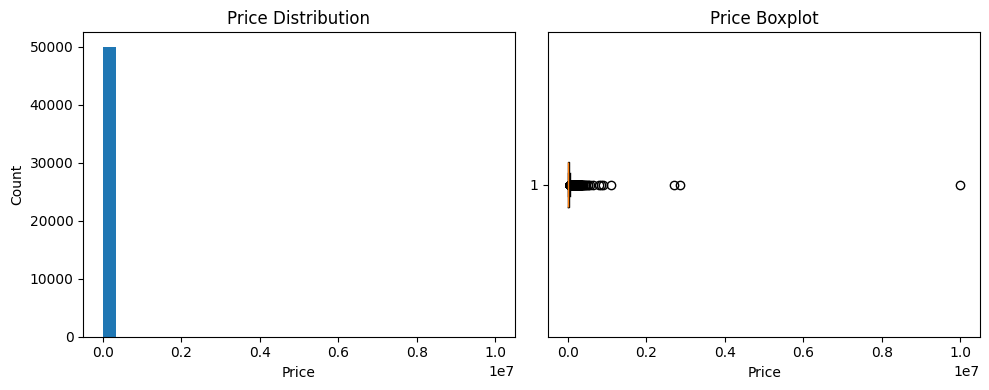

In [ ]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.hist(df_sample["price"].dropna(), bins=30)
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Count")

plt.subplot(1, 2, 2)
plt.boxplot(df_sample["price"].dropna(), vert=False)
plt.title("Price Boxplot")
plt.xlabel("Price")

plt.tight_layout()
plt.show()

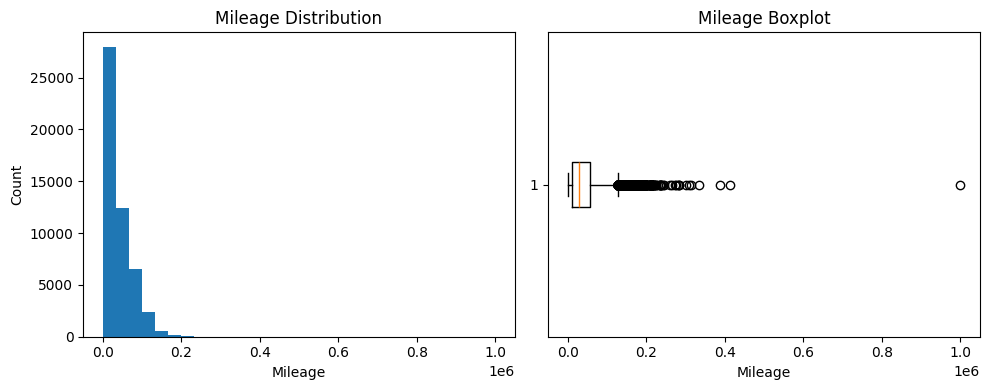

In [ ]:
#  MILEAGE
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.hist(df_sample["mileage"].dropna(), bins=30)
plt.title("Mileage Distribution")
plt.xlabel("Mileage")
plt.ylabel("Count")

plt.subplot(1, 2, 2)
plt.boxplot(df_sample["mileage"].dropna(), vert=False)
plt.title("Mileage Boxplot")
plt.xlabel("Mileage")

plt.tight_layout()
plt.show()

Other numerical columns available:
['public_reference', 'year_of_registration']


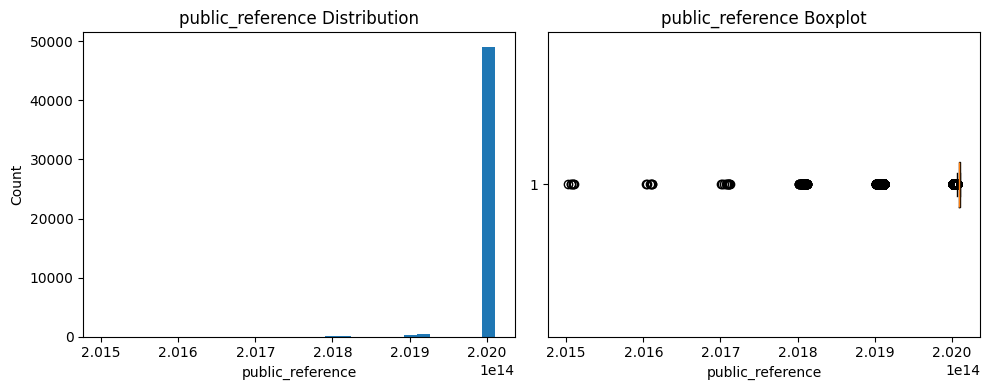

In [ ]:
#  NUMERICAL FEATURE
numeric_cols = df_sample.select_dtypes(include=["int64", "float64"]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c not in ["price", "mileage"]]

print("Other numerical columns available:")
print(numeric_cols)

feature = numeric_cols[0]

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.hist(df_sample[feature].dropna(), bins=30)
plt.title(f"{feature} Distribution")
plt.xlabel(feature)
plt.ylabel("Count")

plt.subplot(1, 2, 2)
plt.boxplot(df_sample[feature].dropna(), vert=False)
plt.title(f"{feature} Boxplot")
plt.xlabel(feature)

plt.tight_layout()
plt.show()

Exploratory Data Analysis – Predictive Relationships

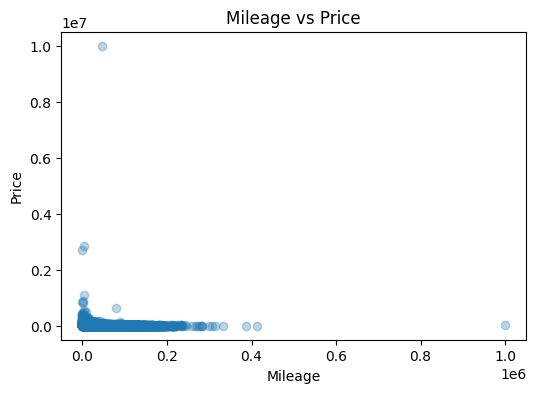

In [ ]:
# Mileage vs Price
plt.figure(figsize=(6, 4))
plt.scatter(df_sample["mileage"], df_sample["price"], alpha=0.3)
plt.xlabel("Mileage")
plt.ylabel("Price")
plt.title("Mileage vs Price")
plt.show()

/tmp/ipython-input-1550019925.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


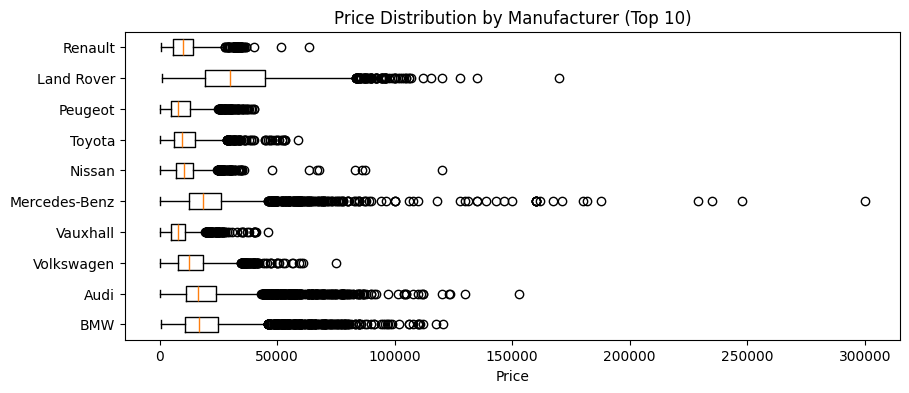

In [ ]:
# Standard Make vs Price
top_makes = df_sample["standard_make"].value_counts().head(10).index

df_make_price = df_sample[df_sample["standard_make"].isin(top_makes)]

plt.figure(figsize=(10, 4))
plt.boxplot(
    [df_make_price[df_make_price["standard_make"] == m]["price"].dropna()
     for m in top_makes],
    labels=top_makes,
    vert=False
)
plt.xlabel("Price")
plt.title("Price Distribution by Manufacturer (Top 10)")
plt.show()

/tmp/ipython-input-3512758684.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


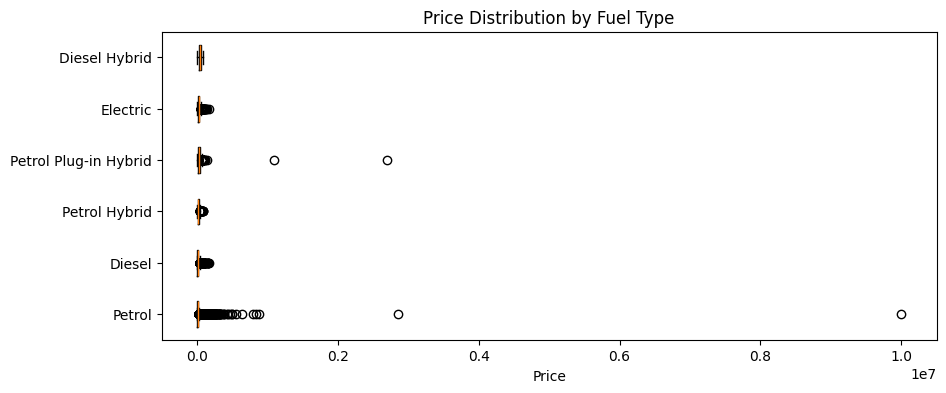

In [ ]:
#  Fuel Type vs Price
top_fuels = df_sample["fuel_type"].value_counts().head(6).index

df_fuel_price = df_sample[df_sample["fuel_type"].isin(top_fuels)]

plt.figure(figsize=(10, 4))
plt.boxplot(
    [df_fuel_price[df_fuel_price["fuel_type"] == f]["price"].dropna()
     for f in top_fuels],
    labels=top_fuels,
    vert=False
)
plt.xlabel("Price")
plt.title("Price Distribution by Fuel Type")
plt.show()

Identify Data Quality Issues

In [ ]:
# Data Quality Issues

print("Missing values per column:")
display(
    df.isnull()
      .sum()
      .sort_values(ascending=False)
      .loc[lambda x: x > 0]
)

Missing values per column:


,0
year_of_registration,33311
reg_code,31857
standard_colour,5378
body_type,837
fuel_type,601
mileage,127


In [ ]:
#  invalid values

# Price
invalid_price = df[df["price"] <= 0]
print("\nNumber of rows with price <= 0:")
print(len(invalid_price))

# Mileage
invalid_mileage = df[df["mileage"] < 0]
print("\nNumber of rows with mileage < 0:")
print(len(invalid_mileage))

# Year of registration
invalid_year = df[
    (df["year_of_registration"] < 1900) |
    (df["year_of_registration"] > 2026)
]
print("\nNumber of rows with unrealistic year_of_registration:")
print(len(invalid_year))


Number of rows with price <= 0:
0

Number of rows with mileage < 0:
0

Number of rows with unrealistic year_of_registration:
17


In [ ]:
#  extreme values
print("\nPrice range:")
print(df["price"].min(), "to", df["price"].max())

print("\nMileage range:")
print(df["mileage"].min(), "to", df["mileage"].max())


Price range:
120 to 9999999

Mileage range:
0.0 to 999999.0


In [ ]:
display(
    df[
        (df["price"] <= 0) |
        (df["mileage"] < 0)
    ].head()
)

,public_reference,mileage,reg_code,standard_colour,standard_make,standard_model,vehicle_condition,year_of_registration,price,body_type,crossover_car_and_van,fuel_type


Data Cleaning

In [ ]:
df_clean = df.copy()

#  Remove invalid values
df_clean = df_clean[df_clean["price"] > 0]

df_clean = df_clean[df_clean["mileage"] >= 0]

df_clean = df_clean[
    (df_clean["year_of_registration"].isna()) |
    (
        (df_clean["year_of_registration"] >= 1900) &
        (df_clean["year_of_registration"] <= 2026)
    )
]

In [ ]:
# Handle missing values

# Numerical
num_cols = df_clean.select_dtypes(include=["int64", "float64"]).columns.tolist()

# Categorical
cat_cols = df_clean.select_dtypes(include=["object"]).columns.tolist()

# missing numerical values
for col in num_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

#  missing categorical values
for col in cat_cols:
    df_clean[col] = df_clean[col].fillna("Unknown")

In [ ]:
#  Handle extreme outliers
price_cap = df_clean["price"].quantile(0.995)
df_clean["price"] = df_clean["price"].clip(upper=price_cap)

In [ ]:
#  Re-check
print("Cleaned dataset shape:", df_clean.shape)

print("\nRemaining missing values:")
display(df_clean.isnull().sum()[df_clean.isnull().sum() > 0])

print("\nCleaned price range:")
print(df_clean["price"].min(), "to", df_clean["price"].max())

Cleaned dataset shape: (401861, 12)

Remaining missing values:


,0



Cleaned price range:
120 to 120000


 Feature Engineering (3 examples)

In [ ]:
df_fe = df_clean.copy()

#  Car age from year_of_registration
current_year = 2026
df_fe["car_age"] = current_year - df_fe["year_of_registration"]

In [ ]:
#  Mileage per year
df_fe["mileage_per_year"] = df_fe["mileage"] / (df_fe["car_age"] + 1)

In [ ]:
# Simplify vehicle condition
df_fe["vehicle_condition_simple"] = df_fe["vehicle_condition"].replace(
    {
        "Used": "Used",
        "New": "New"
    }
)

In [ ]:
# All other values grouped as "Other"
df_fe.loc[
    ~df_fe["vehicle_condition_simple"].isin(["Used", "New"]),
    "vehicle_condition_simple"
] = "Other"

print("New engineered features:")
display(
    df_fe[[
        "year_of_registration",
        "car_age",
        "mileage",
        "mileage_per_year",
        "vehicle_condition",
        "vehicle_condition_simple"
    ]].head()
)

New engineered features:


,year_of_registration,car_age,mileage,mileage_per_year,vehicle_condition,vehicle_condition_simple
0,2016.0,10.0,0.0,0.000000,NEW,Other
1,2011.0,15.0,108230.0,6764.375000,USED,Other
2,2017.0,9.0,7800.0,780.000000,USED,Other
3,2016.0,10.0,45000.0,4090.909091,USED,Other
4,2015.0,11.0,64000.0,5333.333333,USED,Other


 Define Features (X) and Target (y)

In [ ]:
#  Define Features (X) and Target (y)
y = df_fe["price"]

print("Target variable:")
print(y.name)

X = df_fe.drop(columns=["price"])

print("\nNumber of features:", X.shape[1])

num_features = X.select_dtypes(include=["int64", "float64", "bool"]).columns.tolist()
cat_features = X.select_dtypes(include=["object"]).columns.tolist()

print("\nNumerical features:")
print(num_features)

print("\nCategorical features:")
print(cat_features)

Target variable:
price

Number of features: 14

Numerical features:
['public_reference', 'mileage', 'year_of_registration', 'crossover_car_and_van', 'car_age', 'mileage_per_year']

Categorical features:
['reg_code', 'standard_colour', 'standard_make', 'standard_model', 'vehicle_condition', 'body_type', 'fuel_type', 'vehicle_condition_simple']


Train/Test Split

In [ ]:
#  Train/Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=random_state
)

print("Training set size:")
print(X_train.shape, y_train.shape)

print("\nTest set size:")
print(X_test.shape, y_test.shape)

Training set size:
(321488, 14) (321488,)

Test set size:
(80373, 14) (80373,)


Preprocessing Pipeline

In [ ]:
#  Preprocessing Pipeline

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", MinMaxScaler())
])
print("Number of numerical features:", len(num_features))

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

print("Number of categorical features:", len(cat_features))

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_features),
        ("cat", categorical_transformer, cat_features)
    ]
)

Number of numerical features: 6
Number of categorical features: 8


Linear Regression

In [ ]:
# Linear Regression
linreg_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

linreg_model.fit(X_train, y_train)

y_pred_lr = linreg_model.predict(X_test)

lr_mae = mean_absolute_error(y_test, y_pred_lr)
lr_mse = mean_squared_error(y_test, y_pred_lr)
lr_rmse = np.sqrt(lr_mse)
lr_r2 = r2_score(y_test, y_pred_lr)

print("Linear Regression Performance:")
print("MAE :", lr_mae)
print("RMSE:", lr_rmse)
print("R²  :", lr_r2)

Linear Regression Performance:
MAE : 3204.5847148180987
RMSE: 5645.736737236254
R²  : 0.8752935535404354


kNN Regressor + GridSearchCV

In [ ]:
# (one-hot encoding)

ohe = OneHotEncoder(handle_unknown="ignore")

numeric_transformer_knn = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", MinMaxScaler())
])

categorical_transformer_knn = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", ohe)
])

preprocessor_knn = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_knn, num_features),
        ("cat", categorical_transformer_knn, cat_features)
    ]
)

In [ ]:
#  kNN pipeline
knn_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor_knn),
    ("model", KNeighborsRegressor())
])

In [ ]:
# grid search
X_train_gs = X_train.sample(n=15000, random_state=random_state)
y_train_gs = y_train.loc[X_train_gs.index]

print("GridSearch training subset shape:", X_train_gs.shape)

GridSearch training subset shape: (15000, 14)


In [ ]:
# Grid search
param_grid = {
    "model__n_neighbors": [5, 9],
    "model__weights": ["uniform", "distance"],
    "model__p": [2]
}

In [ ]:
# GridSearchCV
gs_knn = GridSearchCV(
    estimator=knn_pipe,
    param_grid=param_grid,
    cv=3,
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)

gs_knn.fit(X_train_gs, y_train_gs)

print("\nBest kNN parameters:")
print(gs_knn.best_params_)

print("\nBest CV MAE (lower is better):")
best_cv_mae = -gs_knn.best_score_
print(best_cv_mae)


Best kNN parameters:
{'model__n_neighbors': 5, 'model__p': 2, 'model__weights': 'distance'}

Best CV MAE (lower is better):
3773.929526214153


In [ ]:
# kNN model
best_knn = gs_knn.best_estimator_
y_pred_knn = best_knn.predict(X_test)

knn_mae = mean_absolute_error(y_test, y_pred_knn)
knn_mse = mean_squared_error(y_test, y_pred_knn)
knn_rmse = np.sqrt(knn_mse)
knn_r2 = r2_score(y_test, y_pred_knn)

print("\nkNN Test Performance:")
print("MAE :", knn_mae)
print("RMSE:", knn_rmse)
print("R²  :", knn_r2)


kNN Test Performance:
MAE : 3411.3823229825875
RMSE: 7397.396221882898
R²  : 0.785905544441187


Decision Tree Regressor + GridSearchCV

In [ ]:
# Decision Tree pipeline
dt_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", DecisionTreeRegressor(random_state=random_state))
])


In [ ]:
# Parameter grid
param_grid_dt = {
    "model__max_depth": [5, 10, 15],
    "model__min_samples_split": [2, 10, 50],
    "model__min_samples_leaf": [1, 5, 20]
}

gs_dt = GridSearchCV(
    estimator=dt_pipe,
    param_grid=param_grid_dt,
    cv=3,
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)

In [ ]:
gs_dt.fit(X_train, y_train)

print("Best Decision Tree parameters:")
print(gs_dt.best_params_)

best_dt_cv_mae = -gs_dt.best_score_
print("\nBest CV MAE (lower is better):")
print(best_dt_cv_mae)

Best Decision Tree parameters:
{'model__max_depth': 15, 'model__min_samples_leaf': 20, 'model__min_samples_split': 2}

Best CV MAE (lower is better):
3731.256054912797


In [ ]:
# best model
best_dt = gs_dt.best_estimator_
y_pred_dt = best_dt.predict(X_test)

dt_mae = mean_absolute_error(y_test, y_pred_dt)
dt_mse = mean_squared_error(y_test, y_pred_dt)
dt_rmse = np.sqrt(dt_mse)
dt_r2 = r2_score(y_test, y_pred_dt)

print("\nDecision Tree Test Performance:")
print("MAE :", dt_mae)
print("RMSE:", dt_rmse)
print("R²  :", dt_r2)


Decision Tree Test Performance:
MAE : 3680.749783924765
RMSE: 6677.469642732093
R²  : 0.8255497875312602


 Model Comparison & Selection

In [ ]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "kNN Regressor",
        "Decision Tree Regressor"
    ],
    "CV MAE": [
        None,
        best_cv_mae,
        best_dt_cv_mae
    ],
    "Test MAE": [
        lr_mae,
        knn_mae,
        dt_mae
    ],
    "Test RMSE": [
        lr_rmse,
        knn_rmse,
        dt_rmse
    ],
    "Test R2": [
        lr_r2,
        knn_r2,
        dt_r2
    ]
})

results

best_model_name = results.loc[results["Test MAE"].idxmin(), "Model"]
print("Selected Best Model (lowest Test MAE):", best_model_name)

Selected Best Model (lowest Test MAE): Linear Regression


Final Evaluation & Plots

In [ ]:
best_model_name = results.loc[results["Test MAE"].idxmin(), "Model"]
print("Selected Best Model (lowest Test MAE):", best_model_name)

if best_model_name == "Linear Regression":
    y_pred_best = y_pred_lr
elif best_model_name == "kNN Regressor":
    y_pred_best = y_pred_knn
elif best_model_name == "Decision Tree Regressor":
    y_pred_best = y_pred_dt
else:
    raise ValueError("Best model name not recognised: " + str(best_model_name))

Selected Best Model (lowest Test MAE): Linear Regression


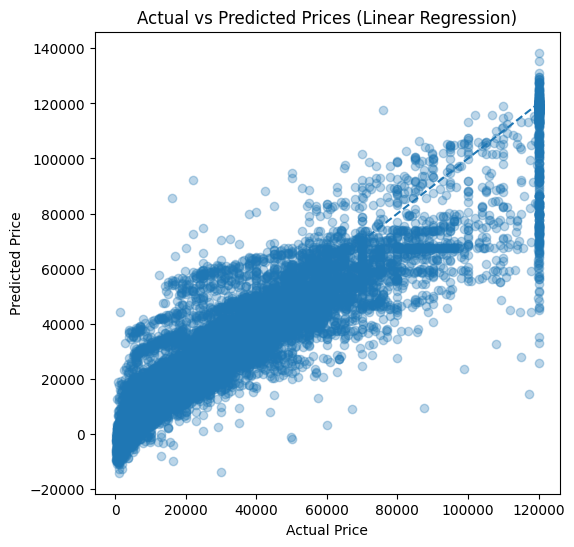

In [ ]:
#  Actual vs Predicted Plot
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_best, alpha=0.3)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title(f"Actual vs Predicted Prices ({best_model_name})")
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)
plt.show()

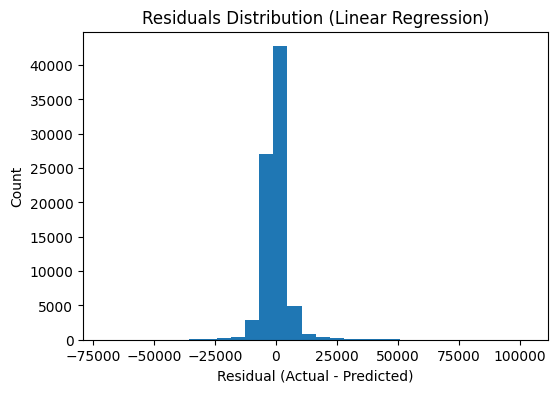

In [ ]:
residuals = y_test - y_pred_best

plt.figure(figsize=(6, 4))
plt.hist(residuals, bins=30)
plt.xlabel("Residual (Actual - Predicted)")
plt.ylabel("Count")
plt.title(f"Residuals Distribution ({best_model_name})")
plt.show()

In [ ]:
# Largest Errors
error_df = X_test.copy()
error_df["Actual_Price"] = y_test
error_df["Predicted_Price"] = y_pred_best
error_df["Absolute_Error"] = np.abs(y_test - y_pred_best)

top_errors = error_df.sort_values("Absolute_Error", ascending=False).head(10)
top_errors

,public_reference,mileage,reg_code,standard_colour,standard_make,standard_model,vehicle_condition,year_of_registration,body_type,crossover_car_and_van,fuel_type,car_age,mileage_per_year,vehicle_condition_simple,Actual_Price,Predicted_Price,Absolute_Error
199412,202006019693280,90000.0,66,Black,BMW,5 Series,USED,2016.0,Saloon,False,Diesel,10.0,8181.818182,Other,117400,14375.977630,103024.022370
39899,202010225296907,54900.0,L,White,BMW,E9,USED,1973.0,Saloon,False,Petrol,53.0,1016.666667,Other,120000,25802.716203,94197.283797
166233,202009123631974,34053.0,J,Silver,Mercedes-Benz,280,USED,1971.0,Convertible,False,Petrol,55.0,608.089286,Other,115000,27777.124784,87222.875216
121687,202002067008941,10.0,Unknown,Blue,Jaguar,XE,NEW,2016.0,Saloon,False,Petrol,10.0,0.909091,Other,120000,33116.811224,86883.188776
221039,202009234106549,620.0,19,Unknown,Land Rover,Discovery 4,USED,2019.0,SUV,False,Diesel,7.0,77.500000,Other,120000,35196.320975,84803.679025
132599,202010255412736,83000.0,60,Grey,Land Rover,Freelander 2,USED,2010.0,SUV,False,Diesel,16.0,4882.352941,Other,87500,9282.903023,78217.096977
333242,202005269556443,1300.0,67,Black,London Taxis International,TX4,USED,2017.0,MPV,False,Diesel,9.0,130.000000,Other,99000,23370.522090,75629.477910
234200,202010124913835,2099.0,66,White,Corvette,Z06,USED,2017.0,Coupe,False,Petrol,9.0,209.900000,Other,107975,32616.853207,75358.146793
202725,202008142481108,1545.0,16,Black,Jaguar,F-Type,USED,2016.0,Convertible,False,Petrol,10.0,140.454545,Other,120000,44955.625899,75044.374101
393198,202010155034134,650.0,66,Blue,Jaguar,F-Type,USED,2016.0,Convertible,False,Petrol,10.0,59.090909,Other,120000,45731.627802,74268.372198


Feature Importance / Interpretation

In [ ]:
num_feature_names = num_features

cat_feature_names = (
    linreg_model
    .named_steps["preprocessor"]
    .named_transformers_["cat"]
    .named_steps["encoder"]
    .get_feature_names_out(cat_features)
)

all_feature_names = np.concatenate([num_feature_names, cat_feature_names])

In [ ]:
coefficients = linreg_model.named_steps["model"].coef_

coef_df = pd.DataFrame({
    "Feature": all_feature_names,
    "Coefficient": coefficients
})

coef_df["Abs_Coefficient"] = coef_df["Coefficient"].abs()

In [ ]:
coef_abs_sorted = coef_df.sort_values("Abs_Coefficient", ascending=False)

print("Top 10 most influential features (by absolute coefficient):")
display(coef_abs_sorted.head(10))

Top 10 most influential features (by absolute coefficient):


,Feature,Coefficient,Abs_Coefficient
1104,standard_model_Shamal,105519.760947,105519.760947
284,standard_model_3500,103817.465637,103817.465637
112,standard_make_Bentley,99866.486881,99866.486881
641,standard_model_Eight,-99239.671817,99239.671817
1208,standard_model_Turbo R,-94381.242184,94381.242184
1158,standard_model_T Series,-93747.168649,93747.168649
1312,standard_model_Z8,93102.848633,93102.848633
434,standard_model_Arnage,-90638.846531,90638.846531
1209,standard_model_Turbo RT,-89527.300463,89527.300463
1002,standard_model_RSQ8,89388.400422,89388.400422


In [ ]:
print("Top 10 least influential features (by absolute coefficient):")
display(coef_abs_sorted.tail(10))

Top 10 least influential features (by absolute coefficient):


,Feature,Coefficient,Abs_Coefficient
900,standard_model_Musso,98.101600,98.101600
80,standard_colour_Brown,-94.833446,94.833446
1034,standard_model_Roomster,85.302432,85.302432
1084,standard_model_Scenic,78.759221,78.759221
88,standard_colour_Multicolour,43.452243,43.452243
427,standard_model_Altea XL,42.740009,42.740009
1299,standard_model_Xsara Picasso,-37.725237,37.725237
731,standard_model_Grand Cherokee,37.723998,37.723998
1161,standard_model_T350,-12.221468,12.221468
1369,vehicle_condition_simple_Other,0.000003,0.000003


In [ ]:
coef_positive = coef_df.sort_values("Coefficient", ascending=False)

print("Top 10 positive coefficients (increase predicted price):")
display(coef_positive.head(10))

Top 10 positive coefficients (increase predicted price):


,Feature,Coefficient,Abs_Coefficient
1104,standard_model_Shamal,105519.760947,105519.760947
284,standard_model_3500,103817.465637,103817.465637
112,standard_make_Bentley,99866.486881,99866.486881
1312,standard_model_Z8,93102.848633,93102.848633
1002,standard_model_RSQ8,89388.400422,89388.400422
404,standard_model_Aero,85533.830083,85533.830083
1061,standard_model_SLR McLaren,80388.196099,80388.196099
1062,standard_model_SLS,77712.550934,77712.550934
1286,standard_model_XJ220,77551.048659,77551.048659
151,standard_make_Lancia,76115.792736,76115.792736


In [ ]:
coef_negative = coef_df.sort_values("Coefficient", ascending=True)

print("Top 10 negative coefficients (decrease predicted price):")
display(coef_negative.head(10))

Top 10 negative coefficients (decrease predicted price):


,Feature,Coefficient,Abs_Coefficient
641,standard_model_Eight,-99239.671817,99239.671817
1208,standard_model_Turbo R,-94381.242184,94381.242184
1158,standard_model_T Series,-93747.168649,93747.168649
434,standard_model_Arnage,-90638.846531,90638.846531
1209,standard_model_Turbo RT,-89527.300463,89527.300463
562,standard_model_Continental,-68953.887883,68953.887883
894,standard_model_Monte Carlo,-68952.697335,68952.697335
684,standard_model_Flying Spur,-61909.169300,61909.169300
469,standard_model_Brooklands,-50530.544587,50530.544587
5,mileage_per_year,-50237.721504,50237.721504
